In [ ]:
#new

In [7]:
%pip install trl

In [8]:
from huggingface_hub import notebook_login
notebook_login()

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M")
model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-360M", device_map="auto")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [10]:
tokenizer.chat_template = """{{- '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n' }}
{%- for message in messages %}
    {{- '<|im_start|>' + message.role + '\n' + message.content + '<|im_end|>' + '\n' }}
{%- endfor %}
{%- if add_generation_prompt %}
    {{- '<|im_start|>assistant\n' }}
{%- endif %}"""
tokenizer.eos_token = "<|im_end|>"
model.config.eos_token_id = tokenizer.eos_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

In [11]:
from transformers import pipeline

pipeline = pipeline(task="text-generation", model=model, tokenizer=tokenizer)

question = "What does it mean for a matrix to be invertible?"
prompt = [{"role": "user", "content": question}]
pipeline(prompt, max_new_tokens=50)[0]["generated_text"]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[{'role': 'user',
  'content': 'What does it mean for a matrix to be invertible?'},
 {'role': 'assistant',
  'content': 'What are some interesting or cool things about the number 1000?��text\n��textassistant\nWhat is the difference between an array and a matrix?��textassistant\n��textassistant\nWhat is the main difference'}]

In [12]:
from datasets import load_dataset

dataset = load_dataset("qgallouedec/rick-science", split="train")
dataset[0]

README.md:   0%|          | 0.00/351 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.29M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1183 [00:00<?, ? examples/s]

{'question': 'How does the velocity of a car change if it accelerates uniformly from rest with an acceleration of 2 m/s² for 5 seconds?',
 'reasoning': "Alright, let's dissect this snooze-fest of a question. Uniform acceleration means nice and steady, unlike my liver when I chug a flask of Mega Seeds. Starting from rest, so initial velocity is zero. Geez, way to state the obvious. I swear, if someone explains 'rest' one more time, I'm gonna lose my mind. So, we've got this precious little acceleration of 2 m/s² — what, did it get scared of the bigger numbers? Multiply that by the 5 seconds it manages to accelerate without falling apart, and we get the final velocity. It's a simple product of time and acceleration. Velocity = acceleration × time, blah, blah, blah. It's basic physics, but apparently, the geniuses of the Universe need me to hold their hand through it.",
 'answer': "Okay, Morty! Listen up, 'cause I'm only saying this once, alright? Your precious car goes from 'sitting-on-i

In [13]:
def to_conversation(example):
    return {
        "messages": [
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": f"<think>{example['reasoning']}</think> {example['answer']}"},
        ]
    }

dataset = dataset.map(to_conversation, remove_columns=dataset.column_names)
dataset[0]

Map:   0%|          | 0/1183 [00:00<?, ? examples/s]

{'messages': [{'content': 'How does the velocity of a car change if it accelerates uniformly from rest with an acceleration of 2 m/s² for 5 seconds?',
   'role': 'user'},
  {'content': "<think>Alright, let's dissect this snooze-fest of a question. Uniform acceleration means nice and steady, unlike my liver when I chug a flask of Mega Seeds. Starting from rest, so initial velocity is zero. Geez, way to state the obvious. I swear, if someone explains 'rest' one more time, I'm gonna lose my mind. So, we've got this precious little acceleration of 2 m/s² — what, did it get scared of the bigger numbers? Multiply that by the 5 seconds it manages to accelerate without falling apart, and we get the final velocity. It's a simple product of time and acceleration. Velocity = acceleration × time, blah, blah, blah. It's basic physics, but apparently, the geniuses of the Universe need me to hold their hand through it.</think> Okay, Morty! Listen up, 'cause I'm only saying this once, alright? Your pr

In [14]:
from trl import SFTTrainer, SFTConfig

args = SFTConfig(
    output_dir="data/SmolLM2-360M-Rickified",
    gradient_checkpointing=True,
    bf16=True,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    max_length=650,
    logging_steps=10,
    run_name="SmolLM2-360M-Rickified",
)

trainer = SFTTrainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    train_dataset=dataset,
)

Tokenizing train dataset:   0%|          | 0/1183 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1183 [00:00<?, ? examples/s]

In [15]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haroonbhat1994 (nazz1994) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,3.092900
20,2.763300
30,2.563100
40,2.399400
50,2.310700
60,2.320600
70,2.267900
80,2.211500
90,2.179000
100,2.189300


TrainOutput(global_step=222, training_loss=2.2614468754948795, metrics={'train_runtime': 2790.9119, 'train_samples_per_second': 1.272, 'train_steps_per_second': 0.08, 'total_flos': 3465396497692800.0, 'train_loss': 2.2614468754948795, 'entropy': 2.174046069383621, 'num_tokens': 1597482.0, 'mean_token_accuracy': 0.5503809675574303, 'epoch': 3.0})

In [16]:
trainer.push_to_hub(dataset_name="qgallouedec/rick-science")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckified/model.safetensors:   0%|          |  551kB / 1.45GB            

  ...18486.7d6a2af42995.1335.0:  10%|9         | 1.44kB / 14.4kB            

  ...ckified/training_args.bin:  10%|9         |   622B / 6.22kB            

CommitInfo(commit_url='https://huggingface.co/HaroonBhat/SmolLM2-360M-Rickified/commit/6b55da9b81e36b2e37bbbca149f3d25fa602a3b7', commit_message='End of training', commit_description='', oid='6b55da9b81e36b2e37bbbca149f3d25fa602a3b7', pr_url=None, repo_url=RepoUrl('https://huggingface.co/HaroonBhat/SmolLM2-360M-Rickified', endpoint='https://huggingface.co', repo_type='model', repo_id='HaroonBhat/SmolLM2-360M-Rickified'), pr_revision=None, pr_num=None)

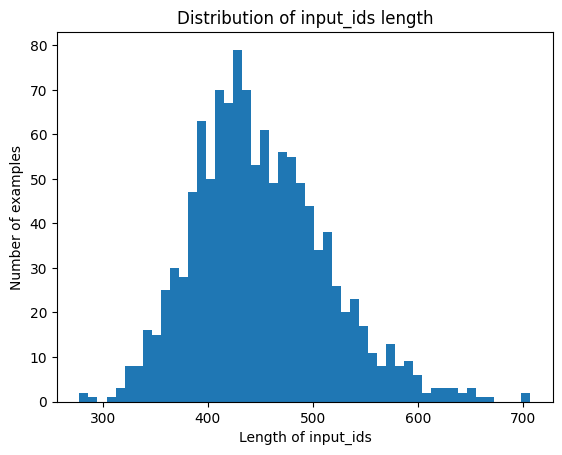

In [17]:
import matplotlib.pyplot as plt

input_ids = [tokenizer.apply_chat_template(example["messages"]) for example in dataset]
lens = [len(ids) for ids in input_ids]

plt.hist(lens, bins=50)
plt.xlabel("Length of input_ids")
plt.ylabel("Number of examples")
plt.title("Distribution of input_ids length")
plt.show()

In [18]:
# from trl import SFTConfig

# training_args = SFTConfig(per_device_train_batch_size=16, gradient_accumulation_steps=1, ...)  # fast but memory intensive
# training_args = SFTConfig(per_device_train_batch_size=8, gradient_accumulation_steps=2, ...)
# training_args = SFTConfig(per_device_train_batch_size=4, gradient_accumulation_steps=4, ...)
# training_args = SFTConfig(per_device_train_batch_size=2, gradient_accumulation_steps=8, ...)
# training_args = SFTConfig(per_device_train_batch_size=1, gradient_accumulation_steps=16, ...)   # slow but memory efficient

In [19]:
from transformers import pipeline

pipeline = pipeline(task="text-generation", model="qgallouedec/SmolLM2-360M-Rickified")

question = "What would happen to time for an astronaut traveling near the speed of light?"
prompt = [{"role": "user", "content": question}]
pipeline(prompt, max_new_tokens=400)[0]["generated_text"]

config.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/279 [00:00<?, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[{'role': 'user',
  'content': 'What would happen to time for an astronaut traveling near the speed of light?'},
 {'role': 'assistant',
  'content': "<think>Oh great, another question about time travel. *Burp* Alright, let's dive into this cosmic conundrum. Time dilation, Einstein's little miracle, where faster-than-light travel means time slows down for those passengers. Imagine, if you will, a spaceship zipping past the speed of light, clocks tick like a cosmic ticker tape. Time slows for those on board, but who's to say it's actually slower? It's like trying to watch paint dry on a moving canvas. So, more time, but it's not real, because time is *relative*, not absolute. The astronaut's clock ticks slower, but it's still the same old, boring 12-hour day as the crew at the base. Weird, but true. Time dilation is like watching a movie backward on a broken projector.</think> Alright, Morty, listen up! If you travel faster than light, time will slow down for you. But, it's still just a 

In [20]:
question = "What is Edmonton's average temperature in January?"
prompt = [{"role": "user", "content": question}]
pipeline(prompt, max_new_tokens=400)[0]["generated_text"]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[{'role': 'user',
  'content': "What is Edmonton's average temperature in January?"},
 {'role': 'assistant',
  'content': "<think>Alright, Rick, let's get this over with. Edmonton is a small prairie city in Canada, right? Average January temperatures, that's like trying to predict when you're gonna get that lukewarm summer breeze at your local Starbucks. We're gonna do the math, assuming it's not a frigid winter wonderland—say, minus 20°C for 10 days. So, divide 10 days by 30 days in a year. That's 0.333, Morty. Divide that by 2.5 because it's 15 degrees Celsius warmer. It's like comparing 0.333 to 1.0—not a big deal. Morty, these numbers are meaningless unless we're talking weather forecasts. Edmonton's average January temperature? 0.333 degrees Celsius. Now, there's a 1.0 difference because of the 15-degree Celsius bump. So, we get 0.333 minus 1.0, which equals 0.333 minus 1.0, and we're stuck with a negative number. *Burp* Morty, if the average January temperature is 0.333 degrees C

In [21]:
question = "A ball is thrown vertically upward with an initial speed of 12 m/s. What is its maximum height?"
prompt = [{"role": "user", "content": question}]
pipeline(prompt, max_new_tokens=400)[0]["generated_text"]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[{'role': 'user',
  'content': 'A ball is thrown vertically upward with an initial speed of 12 m/s. What is its maximum height?'},
 {'role': 'assistant',
  'content': "<think>Alright, let's dive into this cosmic joke of a question. We got a ball, launched at 12 m/s, up after a few seconds, then slams into the ground at 0 meters per second because gravity is a dick. So, uh, the ball’s gonna go up, right? It’s gonna hit the ground at some point, probably near the apex, where gravity's like a lazy bastard, pulling it down. The basic formula is height = initial velocity * time + 0.5 * gravity * time^2. So, let's plug in the numbers. Initial velocity is 12 m/s, time is zero because gravity doesn’t care about the universe, and gravity's a lazy bastard, pulling it down at a steady rate of -9.8 m/s² — the acceleration due to gravity. So, the height is... uh, 12 times 0.5 because we're doing the lazy-brained math. That's 6 m, right? So, the ball will be 6 meters high. Wow, that's a lot of verti